# standard codes

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import requests
import os
import time
from google.colab import userdata
from google.colab import drive
drive.mount('/content/drive')
import json
import glob
from IPython.display import clear_output

Mounted at /content/drive


In [ ]:
tng_api_key = userdata.get('TNG_API_KEY')
baseUrl = 'http://www.tng-project.org/api/'
headers = {"api-key":tng_api_key}

In [ ]:
def get(path, params=None, out_filename=None):
    headers = {"api-key":tng_api_key}
    r = requests.get(path, params=params, headers=headers)
    r.raise_for_status()

    if out_filename is not None:
        with open(out_filename, 'wb') as f:
            f.write(r.content)
        return out_filename

    if r.headers['content-type'] == 'application/json':
        return r.json()

    if 'content-disposition' in r.headers:
        filename = r.headers['content-disposition'].split("filename=")[1]
        with open(filename, 'wb') as f:
            f.write(r.content)
        return filename

    return r

In [ ]:
r = get(baseUrl)

for simulation in r['simulations']: #only get TNG50
    if simulation['name'] == 'TNG50-1':
        url = simulation['url']
        break

tng50 = get(url)

url = 'http://www.tng-project.org/api/TNG50-1/snapshots/z=1.8/'
snapshot = get(url)

#new codes

In [ ]:
drive_path = '/content/drive/MyDrive/docs'
os.makedirs(drive_path, exist_ok=True)

In [ ]:
files = np.sort(glob.glob(f"{drive_path}/sub*.json"))
logs = []
max_lines = 15

def log_message(message):
    logs.append(message)
    if len(logs) > max_lines:
        logs.pop(0) # Remove the oldest message
    clear_output(wait=True)
    for msg in logs:
        print(msg)

for i in range(snapshot['num_groups_subfind']):
    if i % int(snapshot['num_groups_subfind']/1000) == 0:
        log_message(str(i))

    if f"{drive_path}/sub{i}.json" in files:
        log_message(f"skipping i: {i}") # Log skipping
        continue # Skip the download part if file exists

    sub_url = f"http://www.tng-project.org/api/TNG50-1/snapshots/{snapshot['number']}/subhalos/{i}/"
    subhalo = get((sub_url), out_filename=f"{drive_path}/sub{i}.json")

    if i > 6:
        break

skipping i: 1
skipping i: 2
skipping i: 3
skipping i: 4
skipping i: 5
skipping i: 6
skipping i: 7
skipping i: 8
skipping i: 9
skipping i: 10
skipping i: 11
skipping i: 12
skipping i: 13
skipping i: 14
skipping i: 15


In [ ]:
FIRST_FEW = 10
bhmdot = np.zeros(FIRST_FEW) -1
sfr = np.zeros(FIRST_FEW) -1
#bhmdot = np.zeros(len(files)) -1
#sfr = np.zeros(len(files)) -1

print('bhmdot: ', bhmdot)
print("sfr: ", sfr)

save_file = f"{drive_path}/bh_sfr.npz"
if os.path.exists(save_file):
    data = np.load(save_file)
    bhmdot[:FIRST_FEW] = data['bhmdot'][:FIRST_FEW]
    sfr[:FIRST_FEW] = data['sfr'][:FIRST_FEW]
    #bhmdot[:len(data['bhmdot'])] = data['bhmdot']
    #sfr[:len(data['sfr'])] = data['sfr']

print('bhmdot: ', bhmdot)
print("sfr: ", sfr)

#for i in range(len(files)):
for i in range(FIRST_FEW):
    if bhmdot[i] >= 0:
        continue
    if sfr[i] >= 0:
        continue
    with open(files[i], 'r') as fid:
        data = json.load(fid)
    bhmdot[i] = data['bhmdot']
    sfr[i] = data['sfr']
    #if i > 1000:
    if i > FIRST_FEW:
        break
    np.savez_compressed(save_file, bhmdot=bhmdot, sfr=sfr)

bhmdot:  [-1. -1. -1. -1. -1. -1. -1. -1. -1. -1.]
sfr:  [-1. -1. -1. -1. -1. -1. -1. -1. -1. -1.]
bhmdot:  [3.51652e-03 1.66792e-02 5.11530e-04 3.77232e-04 1.01108e-05 7.76301e-04
 8.69693e-04 1.40720e-04 1.02882e-03 8.74955e-03]
sfr:  [4.10991e+02 6.14731e+01 1.57871e+00 5.90594e-01 9.54829e-03 1.07151e+00
 6.12776e+00 2.02951e-01 1.94075e+01 1.82909e+01]


In [ ]:
bhl = bhmdot#[bhmdot != -1].tolist()
sfrl = sfr#[sfr != -1].tolist()

#bins = np.logspace(-4, 3, 100)
bins = np.logspace(-4, 3, 10)

counts1, bin_edges = np.histogram(bhl, bins=bins)
counts2, bin_edges = np.histogram(sfrl, bins=bins)

bin_centers = 0.5*(bin_edges[1:] + bin_edges[:-1])

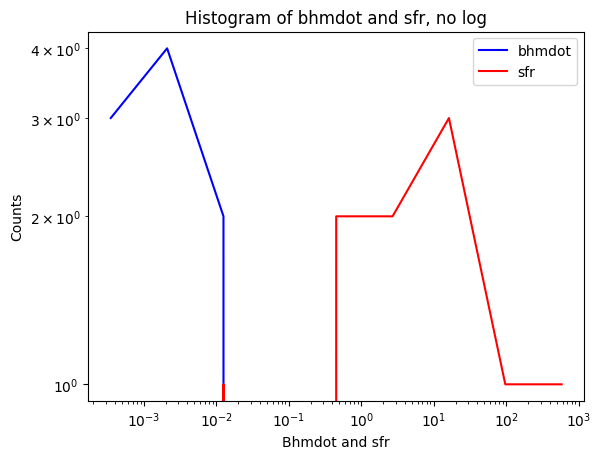

In [ ]:
plt.plot(bin_centers, counts1, label='bhmdot', color='blue')
plt.plot(bin_centers, counts2, label='sfr', color='red')
plt.title('Histogram of bhmdot and sfr, no log')
plt.yscale('log')
plt.xscale('log')
plt.ylabel('Counts')
plt.xlabel('Bhmdot and sfr')
plt.legend()
plt.show()

In [ ]:
bh_median = np.median(bhl)
sfr_median = np.median(sfrl)

bh_mean = np.mean(bhl)
sfr_mean = np.mean(sfrl)

bins1 = np.logspace(-2, 2, 20)
bin_centers1 = 0.5*(bins1[1:] + bins1[:-1])

counts3, _ = np.histogram(bh_median, bins=bins1)
counts4, _ = np.histogram(sfr_median, bins=bins1)
counts5, _ = np.histogram(bh_mean, bins=bins1)
counts6, _ = np.histogram(sfr_mean, bins=bins1)

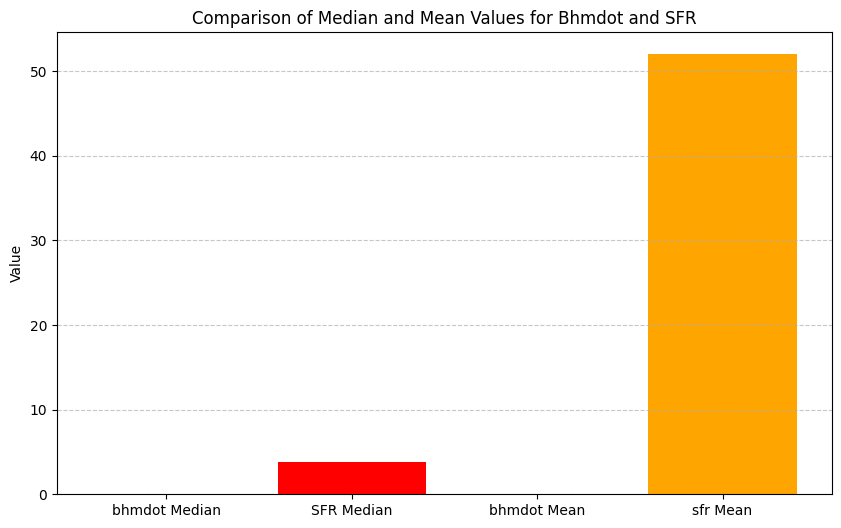

In [ ]:
labels_bar = ['bhmdot Median', 'SFR Median', 'bhmdot Mean', 'sfr Mean']
values = [bh_median, sfr_median, bh_mean, sfr_mean]

plt.figure(figsize=(10, 6))
plt.bar(labels_bar, values, color=['blue', 'red', 'green', 'orange'])
plt.ylabel('Value')
plt.title('Comparison of Median and Mean Values for Bhmdot and SFR')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

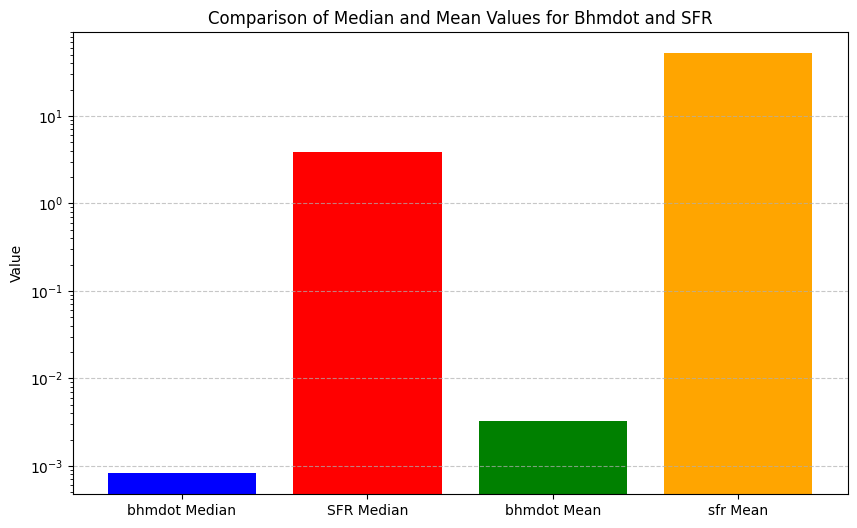

In [ ]:
labels_bar = ['bhmdot Median', 'SFR Median', 'bhmdot Mean', 'sfr Mean']
values = [bh_median, sfr_median, bh_mean, sfr_mean]

plt.figure(figsize=(10, 6))
plt.bar(labels_bar, values, color=['blue', 'red', 'green', 'orange'])
plt.ylabel('Value')
plt.title('Comparison of Median and Mean Values for Bhmdot and SFR')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.yscale("log")
plt.show()